# 01. Integral norms: estimators and convergence

**Question:** given samples of a path, how should the integral norm be estimated?

---

## 0. Setting

### 0.1 Problem

A path $f:[0,T]\to\mathbb{R}^d$ is predicted by $\hat f$, with residual $r = \hat f - f$. The $L^p$ norm and the loss are

$$\|f\|_{L^p} = \Big(\int_0^T |f|^p\Big)^{1/p}, \qquad \text{loss} = \|r\|_{L^p} .$$

We hold samples $(t_i, f(t_i))_{i=0}^n$, not $f$, so the target

$$I(g) = \int_0^T g, \qquad g = |r|^p ,$$

must be estimated by a weighted sum over the samples,

$$Q_w(g) = \sum_i w_i\, g(t_i) .$$

The sample times $t_i$ are given hence the question is the choice of $w$.

### 0.2 Relation to the baseline loss

The baseline is pointwise MSE, the case $w_i = 1/n$. Under uniform sampling

$$\mathrm{MSE} = \frac1n\sum_i r(t_i)^2 \;\xrightarrow[n\to\infty]{}\; \frac1T\int_0^T r^2 \;=\; \frac1T\|r\|_{L^2}^2 ,$$

so the integral norm is the continuum limit of MSE, not a rival to it. Estimating the norm is estimating that limit from finite samples. Under non-uniform sampling the limit changes and MSE no longer reaches it (§3).

### 0.3 Contents

| section | | result |
|---|---|---|
| §1 | Choice of weights | trapezoid |
| §2 | Convergence rates, quoted | quadrature error not a confounder |
| §3 | Non-uniform sampling | MSE converges to the wrong limit |
| §4 | Choice of $p$ | $p=2$, by Lyapunov |
| §5 | Literature | §§1 and 2 standard, §3 is Horvitz-Thompson |

The ML literature on irregularly sampled data (Che et al., 2018; Rubanova et al., 2019; Shukla & Marlin, 2021; Kidger et al., 2020) modifies the model to ingest irregular observations, leaving the objective as pointwise MSE. §5.5.

> **Parallel with sFML.** There, a uniform average over a non-uniformly visited *state* space; here, over a non-uniformly sampled *time* axis.

## 1. Choice of weights

### 1.1 Quadrature rules

Write $\Delta t_i = t_{i+1} - t_i$ for the gaps. Each rule replaces $g$ on a subinterval by an interpolating polynomial and integrates that exactly.

| rule | interpolant | weights |
|---|---|---|
| left Riemann | degree 0, left endpoint | $w_i = \Delta t_i$, $w_n=0$ |
| **trapezoid** | degree 1, both endpoints | $w_i = \tfrac12(\Delta t_{i-1} + \Delta t_i)$ |
| Simpson | degree 2, three points | $\tfrac{1}{3}\Delta t\,(1,4,2,\dots,4,1)$, uniform $\Delta t$ |
| Gauss-Legendre | chooses nodes | weights at roots of the Legendre polynomial $P_n$ |

Simpson's row carries a single spacing because it presupposes a uniform grid; the other rules need no such assumption.


### 1.2 Degree of exactness

An interpolatory rule is exact for polynomials up to the degree of its interpolant (Davis & Rabinowitz, 1984, §2.1). For trapezoid this is degree 1, and the argument is local to each subinterval, so it holds on any grid.

Equal weights $w_i = 1/n$ are exact on constants but not on lines, unless the nodes are symmetric about the midpoint. Both in `test_trapezoid_on_constants_and_lines` and `test_uniform_weights_on_constants_and_lines`.

Exactness to degree 1 for arbitrary node placement is what selects trapezoid. On a uniform grid the two rules differ only near the endpoints, interior weights by $\tfrac1{n(n-1)}$ and endpoints by $\tfrac1{2n}$, so §§1 and 2 are insensitive to the choice.

### 1.3 Error

Standard (Davis & Rabinowitz, 1984): with $h_{\max} = \max_i \Delta t_i$, for $g \in C^2$,

$$\big|I(g) - Q_w(g)\big| \;\le\; \tfrac{T}{12}\,h_{\max}^2\,\|g''\|_\infty ,$$

obtained by summing the local error $-\tfrac1{12}h_i^3 g''(\xi_i)$. Accuracy is limited by curvature and by the widest gap. §2 takes up the case $\|g''\|_\infty = \infty$.

### 1.4 Availability

| rule | exact to degree | requires |
|---|---|---|
| left Riemann | 0 | nothing |
| **trapezoid** | **1** | **nothing** |
| Simpson | 3 | uniform spacing, odd $n$ |
| Gauss-Legendre | $2n-1$ | control of node positions |

Simpson's weights are derived with the middle node at the midpoint; on unequal spacing the coefficients change per triple, so the standard formula is a different rule rather than an inaccurate one. Gauss-Legendre requires choosing where to sample.

**Trapezoid is adopted**: with the nodes given, it is the most accurate rule available. Simpson and Gauss-Legendre appear later only as reference values on grids we control. Error terms as in Davis & Rabinowitz (1984).

### 1.5 The same weights from three other directions

**Signal processing.** Non-uniform FFT and MRI reconstruction estimate an inverse Fourier integral from off-lattice samples. Equal weighting over-counts the dense centre and blurs the image; the correction is inverse local sample density, called **density compensation factors**.

**Survey sampling.** Weighting by inverse inclusion probability gives the Horvitz-Thompson estimator (1952), unbiased under any design. For sample times realising a density $\rho$ on $[0,T]$ with $\int_0^T\rho = 1$, the spacing satisfies $\Delta t_i \approx 1/(n\rho(t_i))$, so trapezoid weights are inverse-probability weights with $\rho$ estimated from the gaps. §3, §5.2.

**Bayesian quadrature.** Put a prior on $f$, condition on the observations, take the weights minimising the posterior variance of $\int f$. Under a Brownian motion prior, encoding continuity and nothing further, the posterior mean is the piecewise linear interpolant and its integral is trapezoid (Diaconis, 1988). Assuming differentiability returns splines.

### 1.6 Cost: bias against variance

The weights are chosen to remove a bias. Assume that $Y_i = g(t_i) + \varepsilon_i$ with $\operatorname{Var}(\varepsilon_i) = \sigma^2$ independent. Normalise $\tilde w_i = w_i/\sum_j w_j$; then

$$\operatorname{Var}\Big(\sum_i \tilde w_i Y_i\Big) = \sigma^2 \sum_i \tilde w_i^{\,2},
\qquad \sum_i \tilde w_i^{\,2} \ge \frac1n \quad\text{(Cauchy-Schwarz)},$$

with equality iff all weights are equal.

> Equal weights minimise variance. Trapezoid weights minimise bias. Nothing does both.

**Effective sample size.** An unweighted average of $m$ observations has variance $\sigma^2/m$. Setting $\sigma^2/m = \sigma^2\sum_i \tilde w_i^{\,2}$ gives Kish's

$$n_{\mathrm{eff}} = \frac{1}{\sum_i \tilde w_i^{\,2}} \le n :$$

the weighted estimator is as noisy as an unweighted average of $n_{\mathrm{eff}}$ observations. Weight concentrated on a few points means the rest contribute little. Equal weights give $n_{\mathrm{eff}} = n$; all weight on one point gives $n_{\mathrm{eff}} = 1$. On the §3 grids, $n = 120$:

| grid | $n_{\mathrm{eff}}$ | variance inflation | $w_{\max}/w_{\min}$ |
|---|---|---|---|
| uniform | 119.5 | $1.00\times$ | 2.0 |
| clustered, $t = u^{0.35}$ | 30.7 | $3.91\times$ | 81.1 |

Zhang & Wang (2016) show the preferable weighting reverses with sampling density; Godambe (1955) proved no best linear unbiased estimator exists even under simple random sampling, so the absence of an unconditional recommendation is a theorem rather than a gap.

Nothing in this notebook is noisy: §3 evaluates deterministic functions, so the variance term is zero there and the bias governs. The cost above is recorded because real data is noisy and weeks 3 to 4 will be.

Noise also adds a bias. With $p=2$, $\mathbb{E}[Q_w(Y^2)] = \int_0^T f^2 + \sigma^2 T + O(h_{\max}^2)$, using $\sum_j w_j = T$; the term $\sigma^2 T$ does not depend on $w$. Removing it requires smoothing before integrating (Ramsay & Silverman, 2005, ch. 3 to 5), not implemented here.

### 1.7 Conclusion

$$\|f\|_{L^p}^p \;\approx\; \sum_{i=0}^n w_i\,|f(t_i)|^p, \qquad w_i = \tfrac12(\Delta t_{i-1} + \Delta t_i),$$

implemented as `integral_norm(t, x, p)` and `integral_distance(t, x, y, p)`.

**Scope.** 
Among rules requiring no assumption on $f$ and no control of the node positions, trapezoid has the highest degree of exactness (§1.2). It is also Bayes-optimal under a continuity prior and unbiased under any sampling design (§1.5). It is the default surviving the fewest assumptions, not an optimum: Godambe (1955) rules out an unconditional best linear unbiased estimator, equal weights win on variance (§1.6), splines win given differentiability, and smoothing before integrating wins given observation noise.

§3 does not depend on the choice. Any consistent estimator of $\int r^2$ shows the same failure of equal weights.

Carried forward: adopt trapezoid; make no noise-robustness claim; report $n_{\mathrm{eff}}$ with every loss value.

In [1]:
%matplotlib inline
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# `pathloss` comes from `pip install -e .`; this line also makes the notebook
# work without it.
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

from pathloss.norms import integral_norm, integral_distance, pointwise_mse
from pathloss.paths import brownian_motion

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (10, 3.6), "figure.dpi": 110})

## 2. Convergence rate

§1 chose the weights. §2 fixes the sample budget, so that §3 cannot be attributed to quadrature error. That the error falls with $n$ is not in question; the point is the rate, which sets how many samples are enough.

Throughout this section the grid is uniform with spacing $h = T/n$ over $n$ intervals.

**Rates.** For $g \in C^2$, trapezoid is $O(h^2)$ and left-Riemann $O(h)$; Davis & Rabinowitz (1984), §2.1 and §2.4. Regressing $\log(\text{error})$ on $\log n$ for $f(t)=e^t$, against its closed-form norm, gives gradients $-2.01$ and $-1.01$: the code attains the stated orders. `test_convergence_rates_on_non_periodic_integrand`.

**Euler-Maclaurin.** Truncating at $m$ terms,

$$\int_a^b g \;=\; h\Big[\tfrac12 g_0 + \cdots + \tfrac12 g_n\Big] \;-\; \sum_{k=1}^{m}\frac{B_{2k}}{(2k)!}\,h^{2k}\Big[g^{(2k-1)}(b) - g^{(2k-1)}(a)\Big] \;+\; R_m ,
\qquad |R_m| \;\le\; \frac{2\zeta(2m)}{(2\pi)^{2m}}\,h^{2m}\int_a^b \big|g^{(2m)}\big| ,$$

with $B_{2k}$ the Bernoulli numbers. Each retained term is a difference of odd derivatives at the endpoints, so for smooth periodic $g$ every one vanishes and only $R_m$ survives, for every $m$: convergence exceeds any power of $h$ (Trefethen & Weideman, 2014). A convergence test on a periodic integrand therefore measures nothing, which rules out $\sin^2$ and is why $e^t$ is used. `test_trapezoid_on_smooth_periodic_integrand`.

**Without $C^2$.** The bound is vacuous for a nowhere-differentiable $g$, and a deterministic $\alpha$-Hölder bound gives only $O(n^{-\alpha})$. For Brownian $W$ that would be $O(n^{-1/2})$, but the per-interval errors are mean-zero Brownian bridge integrals of variance $\Theta(h^3)$, so summing $n$ independent terms gives $\Theta(h^2)$ in variance and an error of order $n^{-1}$: one order worse than the smooth case, not two. Heuristic, not a proof.

**Budget.** A few hundred samples for smooth $g$, where the quadrature error is $O(10^{-6})$ at $n \gtrsim 500$; $10^3$ to $10^4$ for a rough one. Either way four or more orders below the effects §3 measures, so quadrature error is controllable by sampling more densely. §3 turns to an error that is not.

## 3. Non-uniform sampling

### 3.1 The two limits

Let the sample times realise a density $\rho$ on $[0,T]$, $\int_0^T\rho = 1$, so that the fraction of samples in $[t, t+\mathrm{d}t]$ is $\rho(t)\,\mathrm{d}t$. By the law of large numbers,

$$\mathrm{MSE} = \frac1n\sum_i r(t_i)^2 \;\longrightarrow\; \int_0^T r^2\rho ,
\qquad
\frac1T\|r\|_{L^2}^2 \;\longrightarrow\; \frac1T\int_0^T r^2 ,$$

equal for every $r$ iff $\rho \equiv 1/T$.

> MSE integrates the squared residual against the **sampling density**; the integral norm integrates it against **Lebesgue measure**.

Non-uniform nodes do not break quadrature: §1's weights absorb them, and $\Delta t_i \approx 1/(n\rho(t_i))$ is exactly the correction. What they break is the **unweighted** estimator, and by a fixed amount rather than a vanishing one. §3.2 shows the gap surviving $n = 10^6$.

### 3.2 The grid

The demonstration needs a concrete $\rho$. Take the **quantile grid**: with $F$ the CDF of $\rho$,

$$t_i = F^{-1}(u_i), \qquad u_i = \tfrac{i}{n-1} ,$$

whose spacings satisfy $\Delta t_i = 1/\big((n-1)\rho(t_i)\big) + O(n^{-2})$, so it realises $\rho$ to first order and without Monte Carlo noise. A power-law $\rho$ makes $F^{-1}$ a single power. Independent draws from $\rho$ have the same limit with noise on top; both appear below.

### 3.3 Consistency

An estimator converging to the wrong value cannot be repaired by sampling. Below, a residual for which both limits of §3.1 are closed-form, over seven decades of $n$; constants in the code.

In [2]:
alpha = 0.35            # arbitrary choice
r = lambda t: 0.4 * t   # arbitrary choice
L2_limit  = 0.16 / 3                                    # (1/T) int r^2
rho_limit = 0.16 * (1/alpha) / ((1/alpha) + 2)          # int r^2 rho

quantile_grid = lambda n: np.linspace(0, 1, n) ** alpha             # deterministic
def iid_grid(n, seed):                                              # n draws from rho
    u = np.sort(np.random.default_rng(seed).random(n - 2))
    return np.concatenate([[0.0], u, [1.0]]) ** alpha

def quad(tt):
    z = np.zeros((tt.size, 1))
    return float(integral_distance(tt, z, r(tt)[:, None], p=2, normalise=True)) ** 2

print(f"{'n':>9} {'MSE unif':>10} {'MSE quant':>10} {'MSE iid':>10} "
      f"{'quad quant':>11} {'quad iid':>10}")
for k in [4, 6, 8, 10, 12, 16, 20]:
    n = 2**k + 1
    tu, tq, ti = np.linspace(0, 1, n), quantile_grid(n), iid_grid(n, k)
    print(f"{n:>9} {np.mean(r(tu)**2):>10.6f} {np.mean(r(tq)**2):>10.6f} "
          f"{np.mean(r(ti)**2):>10.6f} {quad(tq):>11.6f} {quad(ti):>10.6f}")
print(f"{'limit':>9} {L2_limit:>10.6f} {rho_limit:>10.6f} {rho_limit:>10.6f} "
      f"{L2_limit:>11.6f} {L2_limit:>10.6f}")

        n   MSE unif  MSE quant    MSE iid  quad quant   quad iid
       17   0.055000   0.093124   0.108985    0.054843   0.055433
       65   0.053750   0.093883   0.093944    0.053686   0.053552
      257   0.053438   0.094061   0.093283    0.053416   0.053616
     1025   0.053359   0.094104   0.094067    0.053353   0.053358
     4097   0.053340   0.094114   0.094315    0.053338   0.053335
    65537   0.053334   0.094117   0.094293    0.053334   0.053334
  1048577   0.053333   0.094118   0.094241    0.053333   0.053333
    limit   0.053333   0.094118   0.094118    0.053333   0.053333


MSE converges to $\int_0^1 r^2\rho$, not to $\int_0^1 r^2$: to six decimals on the quantile grid, and with Monte Carlo noise on the independent draws. It is inconsistent, not merely noisy, and $n = 10^6$ does not help. The quadrature estimator reaches the Lebesgue limit in both cases.

### 3.4 Finite samples

Consistency bounds nothing at realistic $n$, and does not separate two failures:

| failure mode | cause | corrected by weights? |
|---|---|---|
| **weighting** | equal weight per sample over-counts dense regions | **yes** |
| **resolution** | the grid does not sample where the residual lives | **no**, the information is absent |

Two residuals separate them: one spread across the domain, resolved by both grids, isolating the weighting effect; one concentrated in a narrow window that the clustered grid barely samples. Both limits for the first are closed-form, so §3.1 predicts the measured values in advance.

In [3]:
T = 1.0
t_fine = np.linspace(0, T, 2**13 + 1)
base = np.sin(2 * np.pi * 2 * t_fine)

# --- residual (a): smooth ramp, resolved by BOTH grids -----------------------
# r(t) = 0.4 t. Non-uniform in time (grows), but nowhere near band-limited by
# the sampling, so any sensible quadrature sees all of it.
g_true = base
g_pred = base + 0.4 * t_fine

# --- residual (b): narrow spike at t = 0.125, MISSED by the clustered grid ---
centre, width, amp = 0.125, 0.075, 0.8
bump = amp * np.exp(-0.5 * ((t_fine - centre) / (width / 2.5)) ** 2)
f_true = base
f_pred = base + bump

n_keep = 120
t_uniform = np.linspace(0, T, n_keep)
t_clustered = T * np.linspace(0, 1, n_keep) ** 0.35     # sparse early

def evaluate(tt, a_fine, b_fine):
    """Score a pair of fine-grid functions as observed on grid `tt`."""
    i = np.searchsorted(t_fine, tt).clip(0, t_fine.size - 1)
    a, b = a_fine[i][:, None], b_fine[i][:, None]
    return (float(integral_distance(tt, a, b, p=2, normalise=True)),
            float(np.sqrt(pointwise_mse(a, b))))

for label, (a_f, b_f) in [("(a) smooth ramp", (g_true, g_pred)),
                          ("(b) narrow spike", (f_true, f_pred))]:
    ref = float(integral_distance(t_fine, a_f[:, None], b_f[:, None], p=2, normalise=True))
    L2_u, MSE_u = evaluate(t_uniform, a_f, b_f)
    L2_c, MSE_c = evaluate(t_clustered, a_f, b_f)
    print(f"{label}   reference (fine grid) = {ref:.5f}")
    print(f"{'  grid':>12} {'L2 (quad)':>12} {'sqrt(MSE)':>12} {'L2 err':>9} {'MSE err':>9}")
    for name, L2, MSE in [("uniform", L2_u, MSE_u), ("clustered", L2_c, MSE_c)]:
        print(f"{name:>12} {L2:>12.5f} {MSE:>12.5f} "
              f"{abs(L2-ref)/ref:>8.1%} {abs(MSE-ref)/ref:>8.1%}")
    print()

(a) smooth ramp   reference (fine grid) = 0.23094
        grid    L2 (quad)    sqrt(MSE)    L2 err   MSE err
     uniform      0.23097      0.23145     0.0%     0.2%
   clustered      0.23136      0.30661     0.2%    32.8%

(b) narrow spike   reference (fine grid) = 0.18448
        grid    L2 (quad)    sqrt(MSE)    L2 err   MSE err
     uniform      0.18447      0.18370     0.0%     0.4%
   clustered      0.03106      0.00820    83.2%    95.6%



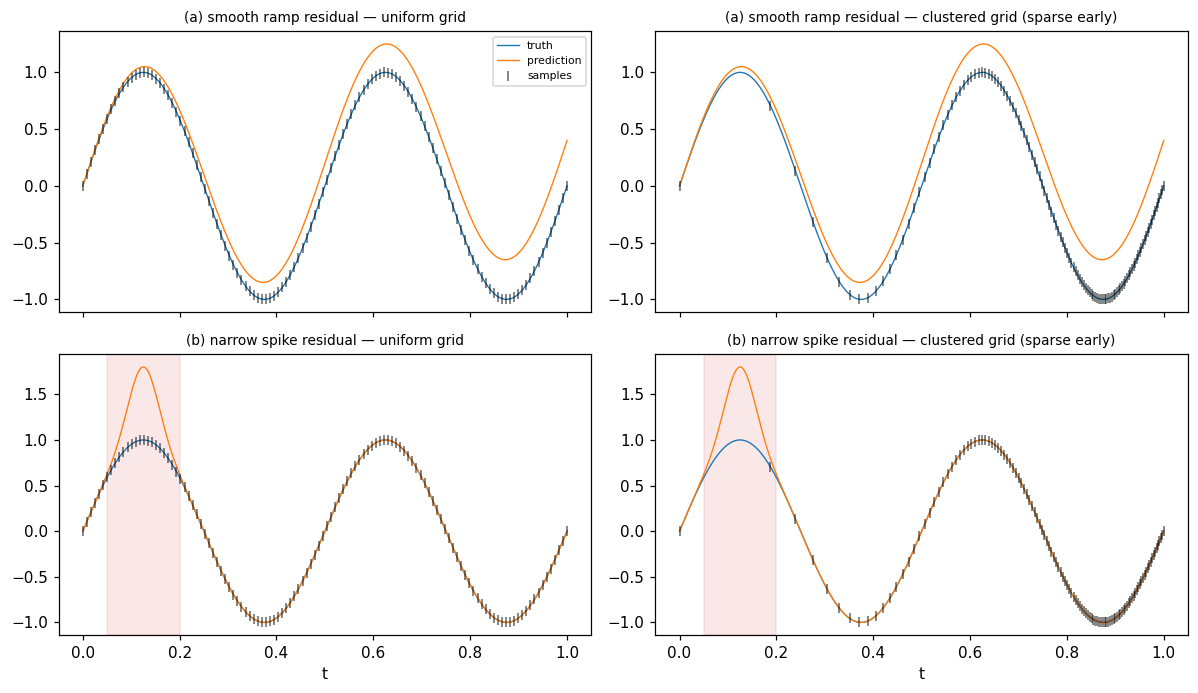

clustered grid has 3 of 120 points in [0, 0.25] (uniform has 30)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharex=True)
for row, (a_f, b_f, tag, shade) in enumerate([
        (g_true, g_pred, "(a) smooth ramp residual", None),
        (f_true, f_pred, "(b) narrow spike residual", (centre - width, centre + width))]):
    for col, (tt, gname) in enumerate([(t_uniform, "uniform grid"),
                                       (t_clustered, "clustered grid (sparse early)")]):
        ax = axes[row, col]
        ax.plot(t_fine, a_f, lw=0.9, label="truth")
        ax.plot(t_fine, b_f, lw=0.9, label="prediction")
        i = np.searchsorted(t_fine, tt).clip(0, t_fine.size - 1)
        ax.plot(tt, a_f[i], "k|", ms=7, alpha=0.6, label="samples")
        if shade is not None:
            ax.axvspan(*shade, color="tab:red", alpha=0.10)
        ax.set_title(f"{tag} — {gname}", fontsize=9)
        if row == 1:
            ax.set_xlabel("t")
        if row == 0 and col == 0:
            ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

n_early = int((t_clustered < 0.25).sum())
print(f"clustered grid has {n_early} of {n_keep} points in [0, 0.25] "
      f"(uniform has {int((t_uniform < 0.25).sum())})")

**Row (a), weighting in isolation.** Both grids resolve the ramp, so only sample placement differs. The weighted $L^2$ distance returns the fine-grid value on both; MSE inflates by a third on the clustered grid. Both agree with the closed-form limits of §3.1 to four significant figures, so the discrepancy is $\int r^2\rho$ against $\int r^2$ and nothing else.

**Row (b), the limit of reweighting.** The clustered grid places 3 of 120 points in $[0,0.25]$; the spike sits at $t = 0.125$. Both measures fail, $L^2$ included. Weights correct the averaging of observations, not their absence.

> Pointwise MSE and the $L^2$ integral norm diverge precisely when the residual and the sampling are both non-uniform in time. Quadrature weighting removes the divergence over the region the grid resolves.

Both conditions hold for irregular observation with time-localised model error, the generic case in clinical measurement, sensor networks and astronomy. By row (b), the robustness experiments in weeks 3 to 4 must report sampling density alongside every loss value.

By §1.5 the weighted distance is the Horvitz-Thompson estimator of $\int r^2$ and MSE the unweighted one. Row (b) is the documented failure of inverse-probability weighting: variance diverges as inclusion probabilities approach zero, and here three points represent a quarter of the domain.

> **Parallel with sFML.** Row (b) has the structure of the noise-floor finding: a quantity differing between two models is invisible to the objective because the data does not separate them.

## 4. Choice of $p$

On a probability space, and $[0,1]$ with Lebesgue measure is one, Lyapunov's inequality gives $\|r\|_{L^p} \le \|r\|_{L^q}$ for $p \le q$, with $\lim_{p\to\infty}\|r\|_{L^p} = \sup_t|r(t)|$. Larger $p$ concentrates the loss on the worst-behaved part of the path. Checked in `test_lp_monotonicity_in_p` and `test_sup_norm`; the $T^{1/p}$ normalisation in `integral_distance` is what makes the values comparable across $p$.

$p=2$ is adopted: it is the value comparable to MSE, and the only $p$ for which $L^p$ is a Hilbert space, which will be required once inner-product structure enters in week 3. $p=\infty$ is retained as a diagnostic.

## 5. Position in the literature

Four strands, separating standard practice from open questions.

### 5.1 Numerical integration on non-uniform grids

§§1 and 2 are textbook: error terms and rules in Davis & Rabinowitz (1984), the periodicity degeneracy in Trefethen & Weideman (2014). The weights appear across applied fields as **density compensation factors**, most visibly in non-uniform FFT and MRI reconstruction. Their function here is to certify that the numerics are not a confounder for §3.

### 5.2 Survey sampling

The weighted estimator is Horvitz & Thompson (1952), and its bias/variance behaviour under near-zero inclusion probabilities accounts for row (b). Three consequences:

- The correction is principled rather than heuristic, and defensible by citation.
- The failure modes are already mapped, so misbehaviour can be predicted rather than discovered.
- The variance-reduction literature (stabilised, trimmed, self-normalised weights) applies if extreme grids destabilise training.

### 5.3 Functional data analysis

Ramsay & Silverman (2005) and Ferraty & Vieu (2006) give the basis-expansion and semi-metric machinery; Wang, Chiou & Müller (2016) review.

**Zhang & Wang (2016)** show the efficiency of equal weight per observation versus equal weight per subject reverses with sampling density: per subject for dense designs, per observation for sparse. The accurate statement of §3 is therefore:

> The preferable weighting is a bias/variance tradeoff depending on the sampling regime. Quadrature weights remove a bias and can add variance. §3 exhibits a regime in which the bias dominates.

Weaker than "MSE is the wrong loss", more defensible, and citable. It also fixes what must be measured in weeks 3 to 4: variance across resamplings, not bias alone.

### 5.4 Non-pointwise losses for time series

An active literature addresses losses beyond pointwise error, on a different axis from ours:

| | corrects | mechanism |
|---|---|---|
| soft-DTW (Cuturi & Blondel, 2017) | misalignment in time | differentiable relaxation of DTW alignment |
| DILATE (Le Guen & Thome, 2019) | shape and timing jointly | soft-DTW with a temporal distortion index |
| patch-wise structural loss (Kudrat et al., 2025) | local structure lost by MSE | patch statistics rather than points |
| **quadrature weighting (this notebook)** | the measure integrated against | $w_i \approx \Delta t_i$ |

DTW assumes reliable samples and wrong correspondence; we assume correct correspondence and wrong weighting. The axes are orthogonal and compose. Signature-based losses address both: reparametrisation invariance for alignment, the integral formulation for measure.

### 5.5 Irregular sampling in machine learning

GRU-D (Che et al., 2018), Latent ODEs (Rubanova et al., 2019), mTAN (Shukla & Marlin, 2021), Neural CDEs (Kidger et al., 2020), surveyed by Shukla & Marlin (2021).

All of it modifies the model, through decay mechanisms, continuous-time dynamics, attention over time or interpolated control paths, and leaves the objective as pointwise MSE or cross-entropy. How the architecture ingests irregular samples has been addressed; what measure the loss should integrate against has not.

By §3 the gap is not cosmetic: a model well designed for irregular sampling can still be trained against an objective that re-weights the time axis by observation density.

### Summary

| section | status |
|---|---|
| §§1 and 2, quadrature | textbook; certification, not contribution |
| §3, weighting | rediscovery of Horvitz-Thompson; novelty in the application to path-to-path losses |
| §4, choice of $p$ | standard $L^p$ theory |

No new mathematics. The unoccupied intersection is **continuous-time models trained on irregularly sampled data with a loss accounting for the sampling measure**, and §3 is evidence that it is non-empty.

## Next steps

1. Port `integral_distance` to a differentiable torch loss in `src/pathloss/losses.py`, weights precomputed per batch, tested against the NumPy version.
2. Add the signature-kernel MMD using `sigkernel` and repeat §3 for it. Reparametrisation invariance predicts greater stability than the integral norm under changes of grid: a falsifiable prediction and a week 3 deliverable.
3. Repeat §3 with missingness in place of irregular sampling.
4. **Replace §3's two grids with a sweep in a scalar measure of sampling non-uniformity** (`docs/logbook/2026-08-09.md`). The divergence depends on $\rho$ only through its departure from uniformity, so $\mathrm{KL}(\rho\,\|\,\mathrm{Unif})$ is the natural abscissa, closed-form in $\alpha$ for $t = u^{\alpha}$. To be raised on Thursday.

---

## References cited in this notebook

Keyed to `papers/references.bib`. PDFs of starred items are in `papers/`.

**Quadrature and numerical integration**
- **Davis & Rabinowitz (1984)**, *Methods of Numerical Integration*: error terms, Gauss-Legendre. §1, §5.1.
- **Trefethen & Weideman (2014)**, *The exponentially convergent trapezoidal rule*, SIAM Review 56(3): the periodic degeneracy. §2, §5.1.

**Weighting and estimation**
- **Horvitz & Thompson (1952)**, JASA 47(260): inverse-probability weighting. §3, §5.2.

**Functional data analysis**
- **Ferraty & Vieu (2006)**: discretised $L^2$ semi-metric, weights $w_j = t_j - t_{j-1}$. §1, §5.3.
- **Ramsay & Silverman (2005)**, ch. 3 to 5: basis expansion, Gram matrices, roughness penalties. §1, §5.3. Route not yet taken.
- **Wang, Chiou & Müller (2016)**, *Annu. Rev. Stat. Appl.* 3: FDA review. §5.3.
- **Zhang & Wang (2016)**, *Ann. Statist.* 44(5): reversal of weighting efficiency with sampling density. §5.3.

**Non-pointwise losses for time series**
- **Cuturi & Blondel (2017)**, soft-DTW, ICML. §5.4.
- **Le Guen & Thome (2019)**, DILATE, NeurIPS. §5.4.
- **Kudrat et al. (2025)**, patch-wise structural loss, ICML. §5.4.

**Irregular sampling in machine learning**
- **Che et al. (2018)**, GRU-D, *Sci. Rep.* 8. §5.5.
- **Rubanova, Chen & Duvenaud (2019)**, Latent ODEs, NeurIPS. §5.5.
- **Shukla & Marlin (2021)**, mTAN, ICLR, and survey arXiv:2012.00168. §5.5.
- **Kidger et al. (2020)**, Neural CDEs, NeurIPS. §5.5.

**Signatures**
- ★ **Salvi et al. (2021)**, *The signature kernel is the solution of a Goursat PDE*. Next steps.

- **Daoudi & Junca (2024)**, *Efficient algorithms computing p-variation*, preprint. §5, §5.6.